
Step Size h = 0.01
x	Euler		Exact		Point Error
0.00	1.000000	1.000000	0.000000
0.01	0.980000	0.980199	0.000199
0.02	0.960400	0.960789	0.000389
0.03	0.941192	0.941765	0.000573
0.04	0.922368	0.923116	0.000748
0.05	0.903921	0.904837	0.000917
0.06	0.885842	0.886920	0.001078
0.07	0.868126	0.869358	0.001233
0.08	0.850763	0.852144	0.001381
0.09	0.833748	0.835270	0.001522
0.10	0.817073	0.818731	0.001658
0.11	0.800731	0.802519	0.001787
0.12	0.784717	0.786628	0.001911
0.13	0.769022	0.771052	0.002029
0.14	0.753642	0.755784	0.002142
0.15	0.738569	0.740818	0.002249
0.16	0.723798	0.726149	0.002351
0.17	0.709322	0.711770	0.002449
0.18	0.695135	0.697676	0.002541
0.19	0.681233	0.683861	0.002629
0.20	0.667608	0.670320	0.002712
0.21	0.654256	0.657047	0.002791
0.22	0.641171	0.644036	0.002866
0.23	0.628347	0.631284	0.002936
0.24	0.615780	0.618783	0.003003
0.25	0.603465	0.606531	0.003066
0.26	0.591395	0.594521	0.003125
0.27	0.579568	0.582748	0.003181
0.28	0.567976	0.571209	0.003233
0.29	0.556617	0.559898	0

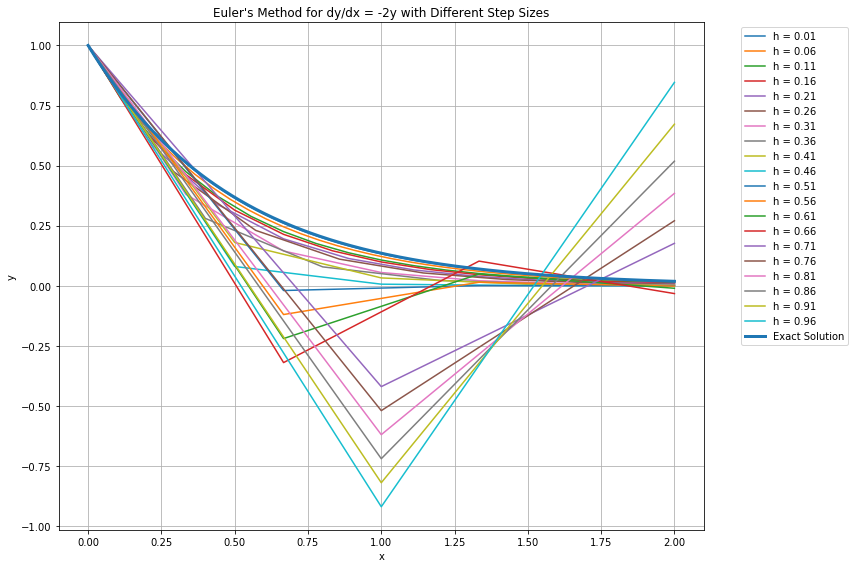

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def exact_solution(x):
    return np.exp(-2 * x)

def f(x, y):
    return -2 * y

# Range of step sizes from 0.01 to 1.00 in increments of 0.05
h_values = np.arange(0.01, 1.01, 0.05)

x_start = 0
x_end = 2

plt.figure(figsize=(12, 8))

# Store the first run to compare against later
first_run_y = None
first_run_x = None

for h in h_values:

    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1

    # Euler's Method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Exact values
    exact_values = exact_solution(x_values)

    # Total accumulated error for this run
    total_error = np.sum(np.abs(exact_values - y_values))

    print(f"\nStep Size h = {h:.2f}")
    print("x\tEuler\t\tExact\t\tPoint Error")

    for i in range(len(x_values)):
        point_error = abs(exact_values[i] - y_values[i])
        print(f"{x_values[i]:.2f}\t{y_values[i]:.6f}\t{exact_values[i]:.6f}\t{point_error:.6f}")

    print(f"Total Accumulated Error = {total_error:.6f}")

    # Compare current run to first run
    if first_run_y is None:
        first_run_y = y_values.copy()
        first_run_x = x_values.copy()
        print("This is the baseline run for comparison.")
    else:
        # Compare using nearest matching indices
        min_length = min(len(first_run_y), len(y_values))

        run_difference = np.sum(
            np.abs(first_run_y[:min_length] - y_values[:min_length])
        )

        print(f"Difference Between Current Run and First Run = {run_difference:.6f}")

    # Plot each run
    plt.plot(x_values, y_values, label=f"h = {h:.2f}")

# Plot exact solution
x_exact = np.linspace(x_start, x_end, 500)
y_exact = exact_solution(x_exact)
plt.plot(x_exact, y_exact, linewidth=3, label="Exact Solution")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for dy/dx = -2y with Different Step Sizes")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()